# Stage Label Generation & Normal Skin Integration

**Disease Stage Logic (Dermatology Literature):**
| Class | Mild | Moderate | Severe |
|-------|------|----------|--------|
| NV (Nevus) | Small, uniform, regular border | Medium, slight asymmetry | Large, multi-colour, irregular |
| MEL (Melanoma) | Thin, small, single colour | Intermediate thickness, partial regression | Thick, large, ulceration |
| BKL (Benign Keratosis) | Small, flat | Medium, slight scaling | Large, thick, hyperkeratotic |
| BCC (Basal Cell Carcinoma) | Nodular <1cm, superficial | Infiltrating, 1-2cm | Morpheaform, >2cm |
| AKIEC (Actinic Keratosis) | Flat, thin erythema | Thick, rough surface | Hypertrophic, lichenoid |
| VASC (Vascular Lesion) | Small, flat angioma | Medium, raised | Large, compound, bleeding risk |
| DF (Dermatofibroma) | Small <0.5cm, flat | 0.5-1cm, slightly raised | >1cm, pigmented, deep |
| NORMAL | N/A (Healthy) | N/A | N/A |

**Stage assignment uses**: lesion area fraction, colour variance, edge irregularity, texture entropy


## Section 1: Install & Import Dependencies

In [1]:
!pip install -q scikit-image tqdm matplotlib seaborn pandas numpy opencv-python-headless Pillow scikit-learn

In [2]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

from PIL import Image, ImageEnhance, ImageFilter
from tqdm import tqdm
from pathlib import Path
from collections import defaultdict
from scipy import stats

import skimage.feature as skf
import skimage.color as skc
import skimage.measure as skm
from skimage.filters import sobel
from sklearn.preprocessing import MinMaxScaler

In [3]:
# Reproducibility
random.seed(42)
np.random.seed(42)

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
PALETTE = sns.color_palette('Set2', 10)

## Section 2: Mount Google Drive & Configuration

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# CONFIGURATION

BALANCED_DATASET_DIR = '/content/drive/MyDrive/DermAugFramework/ISIC2018_Balanced_1000'

NORMAL_RAW_DIR = '/content/drive/MyDrive/DermAugFramework/normal_skin_raw'

FINAL_DATASET_DIR = '/content/drive/MyDrive/DermAugFramework/ISIC2018_Final_8Class'

OUTPUT_DIR = '/content/drive/MyDrive/DermAugFramework/SkinFusionNet_Labels'

TARGET_PER_CLASS = 1000
NORMAL_RAW_COUNT = 124
IMAGE_SIZE       = (224, 224)

# 7 disease classes from ISIC + NORMAL
DISEASE_CLASSES = ['NV', 'MEL', 'BKL', 'BCC', 'AKIEC', 'VASC', 'DF']
ALL_CLASSES     = DISEASE_CLASSES + ['NORMAL']

# Stage label definitions
STAGES = ['mild', 'moderate', 'severe']
# Stage distribution targets per disease (informed by epidemiology)
# NV & DF tend to present mostly mild; MEL often moderate-severe at diagnosis
STAGE_RATIOS = {
    'NV'    : [0.55, 0.30, 0.15],
    'MEL'   : [0.25, 0.40, 0.35],
    'BKL'   : [0.45, 0.35, 0.20],
    'BCC'   : [0.35, 0.40, 0.25],
    'AKIEC' : [0.50, 0.30, 0.20],
    'VASC'  : [0.50, 0.35, 0.15],
    'DF'    : [0.60, 0.30, 0.10],
    'NORMAL': [None, None, None],
}

os.makedirs(FINAL_DATASET_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Configuration set.')
print(f'   Balanced dataset : {BALANCED_DATASET_DIR}')
print(f'   Normal raw imgs  : {NORMAL_RAW_DIR}')
print(f'   Final 8-class dir: {FINAL_DATASET_DIR}')
print(f'   CSV output dir   : {OUTPUT_DIR}')

Configuration set.
   Balanced dataset : /content/drive/MyDrive/DermAugFramework/ISIC2018_Balanced_1000
   Normal raw imgs  : /content/drive/MyDrive/DermAugFramework/normal_skin_raw
   Final 8-class dir: /content/drive/MyDrive/DermAugFramework/ISIC2018_Final_8Class
   CSV output dir   : /content/drive/MyDrive/DermAugFramework/SkinFusionNet_Labels


## Section 3: Normal Skin Augmentation

In [6]:
# ─── Dermatology-aware augmentation for NORMAL skin ───────────────────────

def apply_clahe(img_np):
    """Apply CLAHE to each channel independently (LAB space)."""
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def augment_normal_skin(img_pil, idx):
    """Apply one stochastic augmentation pass to a PIL Image."""
    img = img_pil.copy()

    # 1. Random crop (80–100% of original) then resize
    w, h = img.size
    crop_frac = random.uniform(0.80, 1.0)
    new_w = int(w * crop_frac)
    new_h = int(h * crop_frac)
    left  = random.randint(0, w - new_w)
    top   = random.randint(0, h - new_h)
    img   = img.crop((left, top, left + new_w, top + new_h))
    img   = img.resize(IMAGE_SIZE, Image.LANCZOS)

    # 2. Flip
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_TOP_BOTTOM)

    # 3. Rotation ±30°
    angle = random.uniform(-30, 30)
    img   = img.rotate(angle, resample=Image.BILINEAR, expand=False)

    # 4. Colour jitter
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.85, 1.15))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.85, 1.15))
    img = ImageEnhance.Color(img).enhance(random.uniform(0.90, 1.10))
    img = ImageEnhance.Sharpness(img).enhance(random.uniform(0.8, 1.2))

    # 5. Mild Gaussian blur (50% chance)
    if random.random() > 0.5:
        radius = random.uniform(0.3, 0.8)
        img    = img.filter(ImageFilter.GaussianBlur(radius=radius))

    # 6. CLAHE (60% chance — dermoscopy-style normalisation)
    if random.random() > 0.4:
        img_np = np.array(img)
        img_np = apply_clahe(img_np)
        img    = Image.fromarray(img_np)

    return img

print('Normal skin augmentation functions defined.')

Normal skin augmentation functions defined.


In [7]:
# ─── Run augmentation ──────────────────

NORMAL_OUT_DIR = os.path.join(FINAL_DATASET_DIR, 'NORMAL')
os.makedirs(NORMAL_OUT_DIR, exist_ok=True)

# Load all raw normal images
raw_paths = [
    os.path.join(NORMAL_RAW_DIR, f)
    for f in os.listdir(NORMAL_RAW_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))
]
print(f'Found {len(raw_paths)} raw normal skin images.')
assert len(raw_paths) > 0, '❌ No images found in NORMAL_RAW_DIR — check the path!'

normal_records = []
img_counter    = 0

# Step A: Copy all originals first (resize to IMAGE_SIZE)
for i, p in enumerate(tqdm(raw_paths, desc='[NORMAL] copy originals')):
    try:
        img  = Image.open(p).convert('RGB').resize(IMAGE_SIZE, Image.LANCZOS)
        fname = f'original_{i:04d}.jpg'
        out_p = os.path.join(NORMAL_OUT_DIR, fname)
        img.save(out_p, quality=95)
        normal_records.append({'image_path': out_p, 'label': 'NORMAL', 'source': 'original'})
        img_counter += 1
    except Exception as e:
        print(f'  ⚠️  Skipped {p}: {e}')

print(f'  Originals saved: {img_counter}')

# Step B: Generate augmented images to reach TARGET_PER_CLASS
aug_needed = TARGET_PER_CLASS - img_counter
print(f'  Augmented images needed: {aug_needed}')

aug_counter = 0
for aug_idx in tqdm(range(aug_needed), desc='[NORMAL] augmenting'):
    src_path = random.choice(raw_paths)
    try:
        img     = Image.open(src_path).convert('RGB')
        img_aug = augment_normal_skin(img, aug_idx)
        fname   = f'aug_{aug_idx:05d}.jpg'
        out_p   = os.path.join(NORMAL_OUT_DIR, fname)
        img_aug.save(out_p, quality=95)
        normal_records.append({'image_path': out_p, 'label': 'NORMAL', 'source': 'aug'})
        aug_counter += 1
    except Exception as e:
        print(f'  ⚠️  Aug {aug_idx} failed: {e}')

total_normal = len(os.listdir(NORMAL_OUT_DIR))
status = '✅' if total_normal == TARGET_PER_CLASS else '⚠️'
print(f'\n{status} NORMAL class total: {total_normal} / {TARGET_PER_CLASS}')

Found 124 raw normal skin images.


[NORMAL] copy originals: 100%|██████████| 124/124 [00:12<00:00,  9.75it/s]


  Originals saved: 124
  Augmented images needed: 876


[NORMAL] augmenting: 100%|██████████| 876/876 [01:06<00:00, 13.09it/s]



✅ NORMAL class total: 1000 / 1000


Visualising augmented normal skin samples...


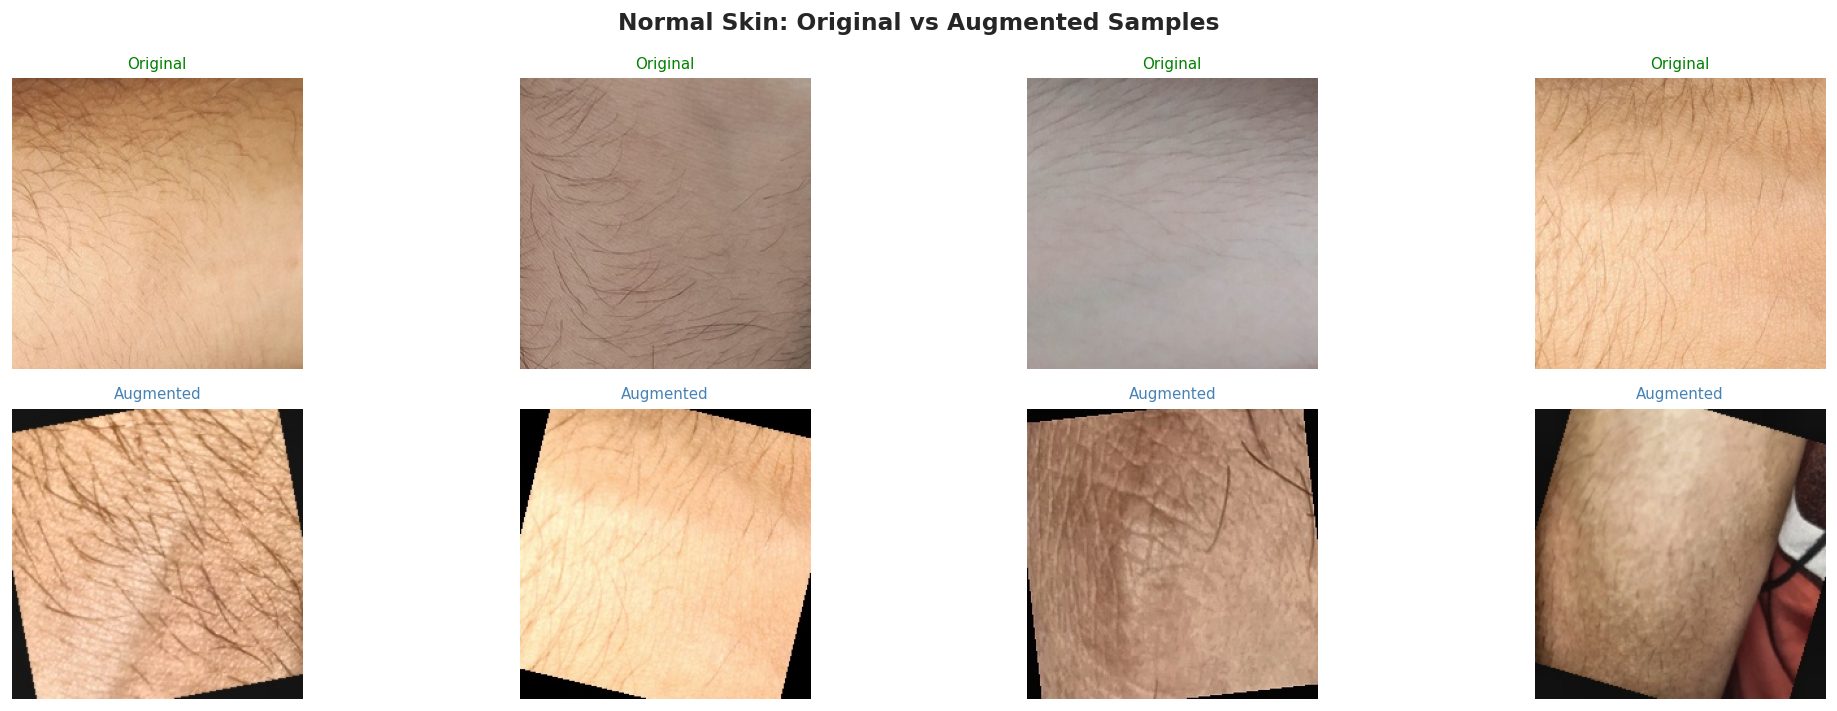

Saved: viz_normal_skin_samples.png


In [11]:
# ─── Visualisation 1: Normal Skin Sample Grid ─────────────────────────────
print('Visualising augmented normal skin samples...')

all_normal_imgs = [f for f in os.listdir(NORMAL_OUT_DIR) if f.endswith('.jpg')]
orig_imgs = [f for f in all_normal_imgs if f.startswith('original')][:4]
aug_imgs  = [f for f in all_normal_imgs if f.startswith('aug')][:8]

fig, axes = plt.subplots(2, 4, figsize=(18, 6))
fig.suptitle('Normal Skin: Original vs Augmented Samples', fontsize=14, fontweight='bold')

for idx, fname in enumerate(orig_imgs):
    img = Image.open(os.path.join(NORMAL_OUT_DIR, fname))
    axes[0, idx].imshow(img)
    axes[0, idx].set_title('Original', fontsize=9, color='green')
    axes[0, idx].axis('off')

# Hide unused top-row axes
for i in range(len(orig_imgs), 4):
    axes[0, i].axis('off')

for idx, fname in enumerate(aug_imgs[:4]):
    img = Image.open(os.path.join(NORMAL_OUT_DIR, fname))
    axes[1, idx].imshow(img)
    axes[1, idx].set_title('Augmented', fontsize=9, color='steelblue')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_normal_skin_samples.png'), bbox_inches='tight')
plt.show()
print('Saved: viz_normal_skin_samples.png')

## Section 4: Copy Disease Classes → Final Dataset & Build Initial Metadata

In [12]:
# ─── Copy 7 disease classes from balanced dataset to final folder ──────────
# NORMAL class was already created in Section 2 inside FINAL_DATASET_DIR

print('Copying disease classes to final dataset folder...')
disease_records = []

for cls in tqdm(DISEASE_CLASSES, desc='Copying classes'):
    src_cls_dir = os.path.join(BALANCED_DATASET_DIR, cls)
    dst_cls_dir = os.path.join(FINAL_DATASET_DIR, cls)

    if not os.path.exists(src_cls_dir):
        print(f'Missing class dir: {src_cls_dir}')
        continue

    os.makedirs(dst_cls_dir, exist_ok=True)

    files = [f for f in os.listdir(src_cls_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for fname in files:
        src = os.path.join(src_cls_dir, fname)
        dst = os.path.join(dst_cls_dir, fname)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
        prefix = fname.split('_')[0]
        disease_records.append({
            'image_path': dst,
            'label'     : cls,
            'source'    : prefix,
        })

print(f'Disease records loaded: {len(disease_records)}')

# Combine with normal records
all_records = disease_records + normal_records
meta_df = pd.DataFrame(all_records)

print(f'Total records (all 8 classes): {len(meta_df)}')
print('Class distribution:')
print(meta_df['label'].value_counts())

Copying disease classes to final dataset folder...


Copying classes: 100%|██████████| 7/7 [04:31<00:00, 38.85s/it]

Disease records loaded: 7000
Total records (all 8 classes): 8000
Class distribution:
label
NV        1000
MEL       1000
BKL       1000
BCC       1000
AKIEC     1000
VASC      1000
DF        1000
NORMAL    1000
Name: count, dtype: int64


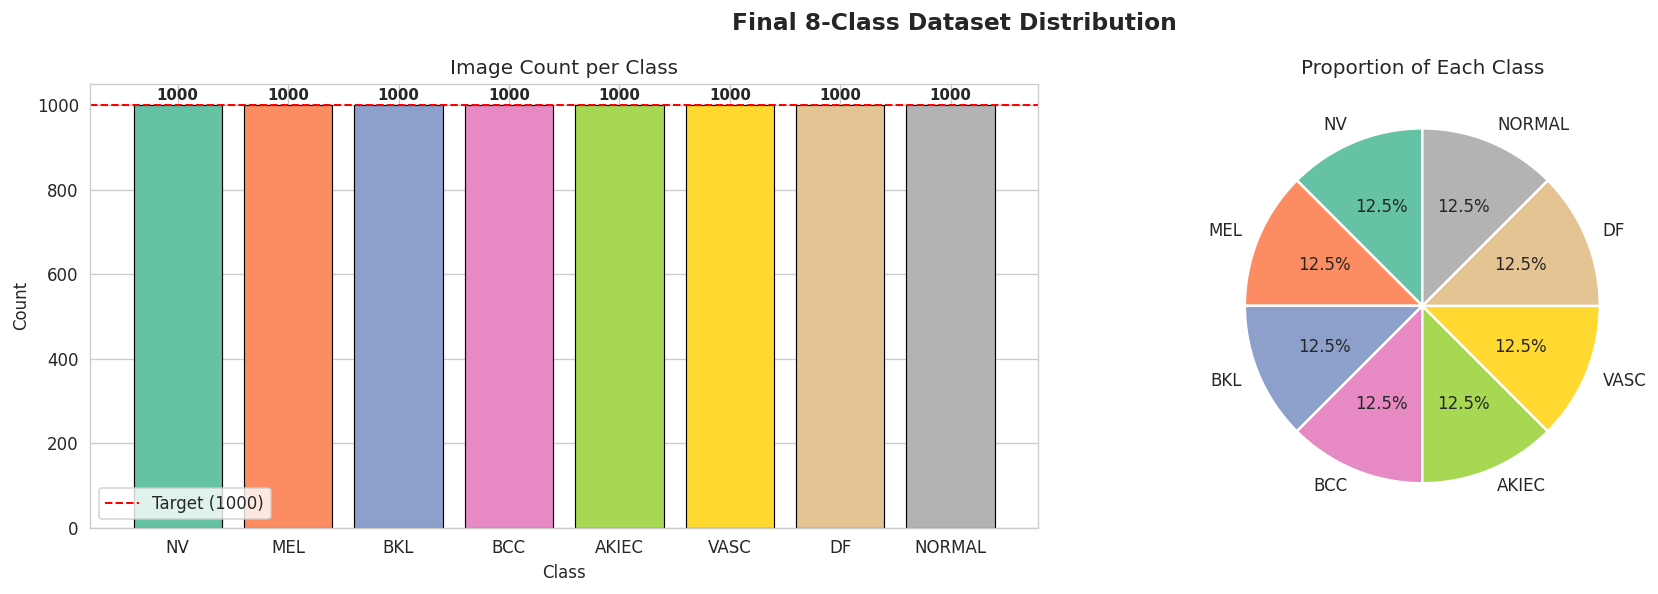

Saved: viz_class_distribution.png


In [13]:
# ─── Visualisation 2: Class Distribution Bar Chart ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Final 8-Class Dataset Distribution', fontsize=14, fontweight='bold')

# Bar chart
counts = meta_df['label'].value_counts().reindex(ALL_CLASSES)
colors = [PALETTE[i] for i in range(len(ALL_CLASSES))]
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Image Count per Class', fontsize=12)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].axhline(y=1000, color='red', linestyle='--', linewidth=1.2, label='Target (1000)')
axes[0].legend()
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proportion of Each Class', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_class_distribution.png'), bbox_inches='tight')
plt.show()
print('Saved: viz_class_distribution.png')

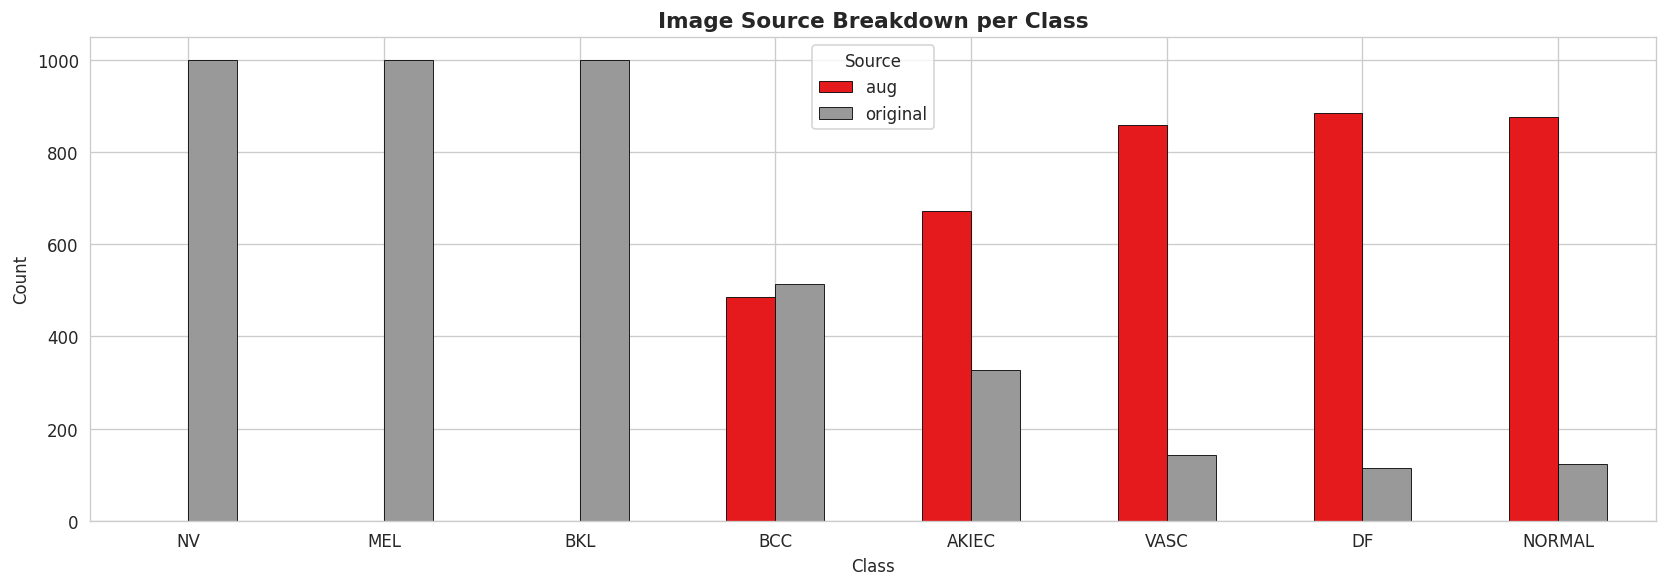

Saved: viz_source_breakdown.png


In [14]:
# ─── Visualisation 3: Source Distribution ──────────
source_pivot = meta_df.groupby(['label','source']).size().unstack(fill_value=0)
source_pivot = source_pivot.reindex(ALL_CLASSES)

fig, ax = plt.subplots(figsize=(14, 5))
source_pivot.plot(kind='bar', ax=ax, colormap='Set1', edgecolor='black', linewidth=0.5)
ax.set_title('Image Source Breakdown per Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Source')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_source_breakdown.png'), bbox_inches='tight')
plt.show()
print('Saved: viz_source_breakdown.png')

## Section 5: Image Feature Extraction for Stage Labelling

Extract 5 dermatologically-relevant image features for each image:

| Feature | Dermatological Relevance |
|---------|-------------------------|
| **Lesion Area Fraction** | Larger lesions → higher severity |
| **Colour Variance** | More colour variation → more atypical/severe |
| **Edge Irregularity** | Irregular/ragged borders → higher severity |
| **Texture Entropy** | Complex texture (scaling, ulceration) → severity |
| **Dark Pixel Fraction** | Dark/pigmented regions → melanoma staging |

These are combined into a **composite severity score** per image, then used with class-specific thresholds to assign Mild/Moderate/Severe labels.


In [15]:
# ─── Feature Extraction Functions ─────────────────────────────────────────

def extract_lesion_area_fraction(img_np):
    """
    Approximate lesion area fraction using Otsu thresholding on the
    desaturated image. Background is typically light in dermoscopy.
    Returns fraction of 'dark' (lesion) pixels.
    """
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    fraction = np.sum(thresh > 0) / thresh.size
    return float(fraction)

def extract_colour_variance(img_np):
    """
    Mean of per-channel standard deviations — proxy for colour heterogeneity.
    High variance → atypical pigmentation (higher stage).
    """
    variances = [np.std(img_np[:, :, c]) for c in range(3)]
    return float(np.mean(variances))

def extract_edge_irregularity(img_np):
    """
    Mean Sobel edge magnitude — proxy for border irregularity.
    Sharp, complex edges → irregular border (higher stage).
    """
    gray     = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    edge_mag = sobel(gray)
    return float(np.mean(edge_mag))

def extract_texture_entropy(img_np):
    """
    Shannon entropy of the grayscale histogram — proxy for surface texture
    complexity (scaling, crusting, ulceration → higher entropy).
    """
    gray  = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    hist  = np.histogram(gray, bins=256, range=(0, 256))[0]
    hist  = hist / hist.sum() + 1e-10
    entr  = -np.sum(hist * np.log2(hist))
    return float(entr)

def extract_dark_pixel_fraction(img_np, threshold=60):
    """
    Fraction of pixels darker than `threshold` in LAB L-channel.
    Useful for melanoma and pigmented lesion staging.
    """
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    L   = lab[:, :, 0]
    return float(np.mean(L < threshold))

def extract_features(img_path):
    """Load image and return dict of all 5 features."""
    try:
        img    = Image.open(img_path).convert('RGB').resize(IMAGE_SIZE)
        img_np = np.array(img)
        return {
            'feat_lesion_area'    : extract_lesion_area_fraction(img_np),
            'feat_colour_var'     : extract_colour_variance(img_np),
            'feat_edge_irreg'     : extract_edge_irregularity(img_np),
            'feat_texture_entropy': extract_texture_entropy(img_np),
            'feat_dark_pixel'     : extract_dark_pixel_fraction(img_np),
        }
    except Exception as e:
        return {
            'feat_lesion_area'    : np.nan,
            'feat_colour_var'     : np.nan,
            'feat_edge_irreg'     : np.nan,
            'feat_texture_entropy': np.nan,
            'feat_dark_pixel'     : np.nan,
        }

print('Feature extraction functions defined.')

Feature extraction functions defined.


In [16]:
# ─── Run feature extraction on all images ─────────────────────────────────

print(f'Extracting features from {len(meta_df)} images...')

FEAT_CACHE = os.path.join(OUTPUT_DIR, 'feature_cache.csv')

# If cache exists, load it (resumable)
if os.path.exists(FEAT_CACHE):
    feat_df = pd.read_csv(FEAT_CACHE)
    print(f'  Loaded cached features: {len(feat_df)} records.')
    # Merge with meta_df to find any missing
    done_paths = set(feat_df['image_path'].tolist())
    pending_df = meta_df[~meta_df['image_path'].isin(done_paths)]
    print(f'  Pending: {len(pending_df)} images.')
else:
    feat_df    = pd.DataFrame()
    pending_df = meta_df.copy()

feat_records = feat_df.to_dict('records') if len(feat_df) > 0 else []

SAVE_EVERY = 500
for i, row in enumerate(tqdm(pending_df.itertuples(index=False), total=len(pending_df),
                              desc='Extracting features')):
    feats = extract_features(row.image_path)
    feats['image_path'] = row.image_path
    feats['label']      = row.label
    feats['source']     = row.source
    feat_records.append(feats)

    # Save checkpoint every SAVE_EVERY images
    if (i + 1) % SAVE_EVERY == 0:
        pd.DataFrame(feat_records).to_csv(FEAT_CACHE, index=False)

feat_df = pd.DataFrame(feat_records)
feat_df.to_csv(FEAT_CACHE, index=False)
print(f'Feature extraction complete. Total: {len(feat_df)} records.')
print(f'   Saved to: {FEAT_CACHE}')
feat_df.head(3)

Extracting features from 8000 images...


Extracting features: 100%|██████████| 8000/8000 [01:39<00:00, 80.11it/s]


Feature extraction complete. Total: 8000 records.
   Saved to: /content/drive/MyDrive/DermAugFramework/SkinFusionNet_Labels/feature_cache.csv


,feat_lesion_area,feat_colour_var,feat_edge_irreg,feat_texture_entropy,feat_dark_pixel,image_path,label,source
0,0.562161,17.969347,0.010390,6.083232,0.000000,/content/drive/MyDrive/DermAugFramework/ISIC20...,NV,original
1,0.253866,38.867824,0.013337,6.894242,0.035953,/content/drive/MyDrive/DermAugFramework/ISIC20...,NV,original
2,0.262038,13.042427,0.005241,5.328883,0.000000,/content/drive/MyDrive/DermAugFramework/ISIC20...,NV,original


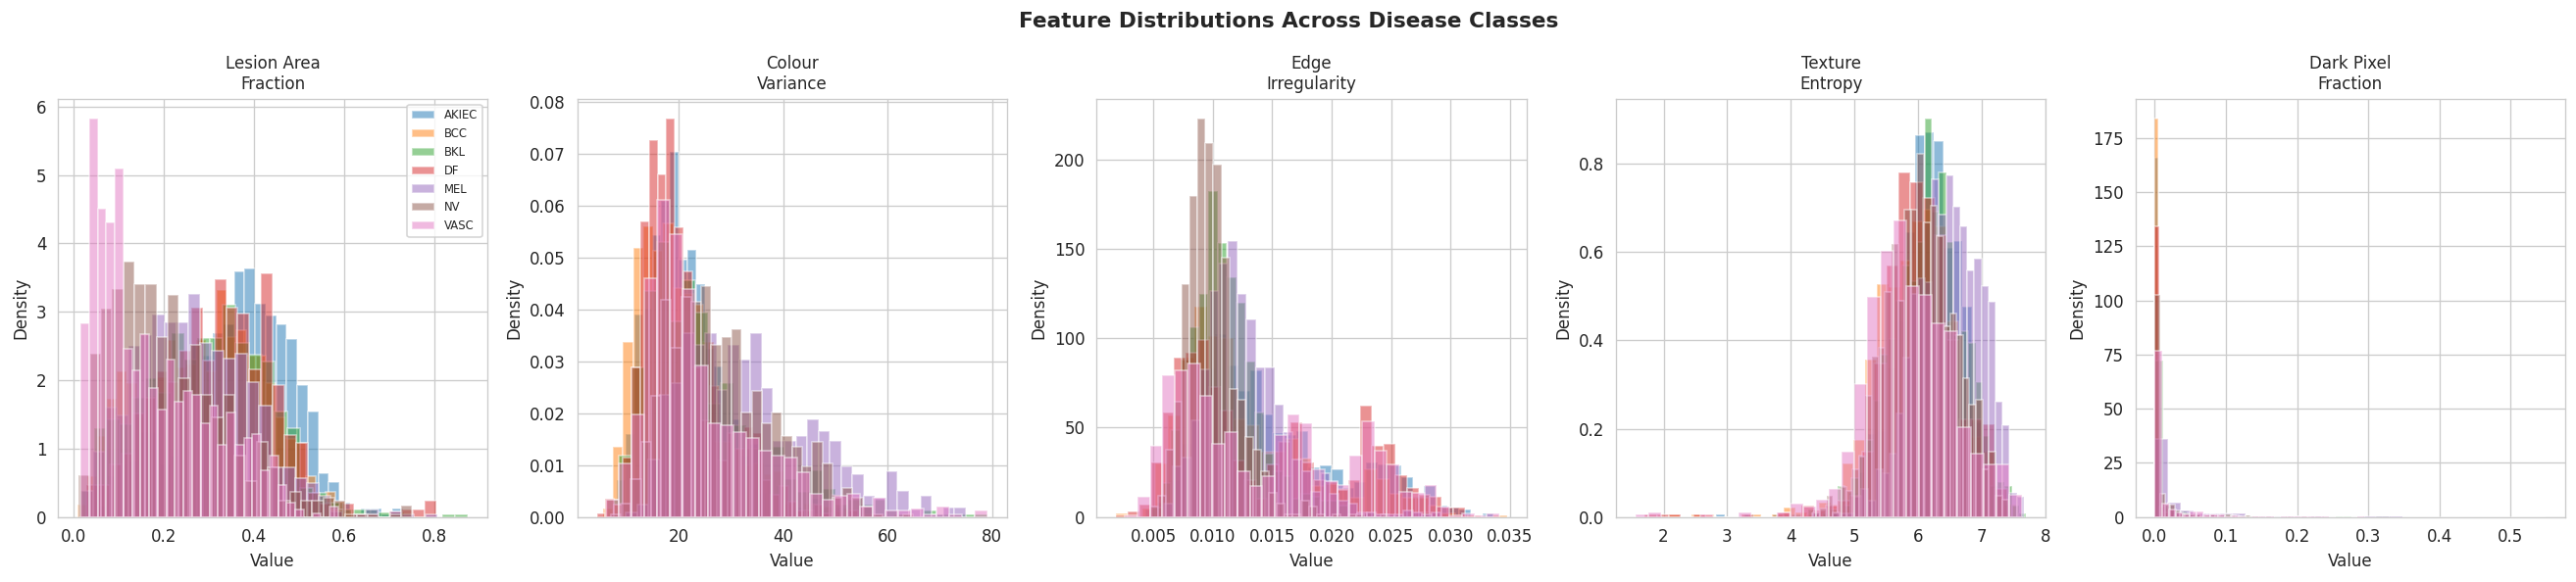

Saved: viz_feature_distributions.png


In [17]:
# ─── Visualisation 4: Feature Distributions per Class ─────────────────────
feat_cols = ['feat_lesion_area', 'feat_colour_var', 'feat_edge_irreg',
             'feat_texture_entropy', 'feat_dark_pixel']
feat_labels = ['Lesion Area\nFraction', 'Colour\nVariance',
               'Edge\nIrregularity', 'Texture\nEntropy', 'Dark Pixel\nFraction']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Feature Distributions Across Disease Classes', fontsize=13, fontweight='bold')

disease_feat_df = feat_df[feat_df['label'] != 'NORMAL']

for ax, col, lbl in zip(axes, feat_cols, feat_labels):
    for cls, grp in disease_feat_df.groupby('label'):
        vals = grp[col].dropna()
        ax.hist(vals, bins=30, alpha=0.5, density=True, label=cls)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')

axes[0].legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_feature_distributions.png'), bbox_inches='tight')
plt.show()
print('Saved: viz_feature_distributions.png')

## Section 6: Clinically Meaningful Stage Label Assignment

**Method:**
1. For each disease class separately, normalise the 5 features to [0,1]
2. Compute a **weighted composite severity score** using clinically motivated weights
3. Assign stages using the **class-specific epidemiological ratios**
4. NORMAL images receive `stage = 'none'`

**Why per-class normalisation?** Feature scales differ between diseases — a large lesion area in DF (small fibroma) is different from a large area in MEL. Normalising within each class respects these differences.


In [19]:
# ─── Stage Assignment ──────────────────────────────────────────────────────

# Clinically motivated feature weights for composite severity score
# Weight rationale (per dermatology literature):
#  lesion_area    → larger lesions more severe (all classes)
#  colour_var     → colour variegation is ABCD criterion C
#  edge_irreg     → border irregularity is ABCD criterion B
#  texture_entropy→ surface texture: scaling/hyperkeratosis = severity
#  dark_pixel     → dark pigmentation: relevant for MEL, NV especially
FEATURE_WEIGHTS = {
    'NV'   : [0.25, 0.20, 0.25, 0.15, 0.15],
    'MEL'  : [0.20, 0.25, 0.25, 0.15, 0.15],
    'BKL'  : [0.25, 0.15, 0.20, 0.25, 0.15],
    'BCC'  : [0.30, 0.20, 0.25, 0.15, 0.10],
    'AKIEC': [0.20, 0.15, 0.25, 0.30, 0.10],
    'VASC' : [0.30, 0.25, 0.20, 0.15, 0.10],
    'DF'   : [0.30, 0.15, 0.25, 0.15, 0.15],
}

scaler = MinMaxScaler()
stage_results = []

for cls in tqdm(DISEASE_CLASSES, desc='Assigning stages'):
    cls_df = feat_df[feat_df['label'] == cls].copy()
    cls_df = cls_df.dropna(subset=feat_cols)

    if len(cls_df) == 0:
        print(f'No data for class {cls}, skipping.')
        continue

    # Normalise features to [0,1] within this class
    feats_np = cls_df[feat_cols].values.astype(np.float32)
    feats_norm = scaler.fit_transform(feats_np)

    # Composite severity score
    w = np.array(FEATURE_WEIGHTS[cls])
    severity_score = feats_norm @ w  # dot product
    cls_df = cls_df.copy()
    cls_df['severity_score'] = severity_score

    # Sort by severity score, assign stages using epidemiological ratios
    cls_df = cls_df.sort_values('severity_score').reset_index(drop=True)
    n      = len(cls_df)
    ratios = STAGE_RATIOS[cls]
    n_mild = int(np.round(n * ratios[0]))
    n_mod  = int(np.round(n * ratios[1]))
    n_sev  = n - n_mild - n_mod
    # Ensure no negative counts
    n_sev  = max(n_sev, 0)

    stages_arr = (['mild'] * n_mild +
                  ['moderate'] * n_mod +
                  ['severe'] * n_sev)
    # Pad/trim to length n just in case
    stages_arr = (stages_arr + ['moderate'] * n)[:n]

    cls_df['stage'] = stages_arr
    cls_df['stage_numeric'] = cls_df['stage'].map({'mild': 0, 'moderate': 1, 'severe': 2})

    stage_results.append(cls_df)
    print(f'  {cls:6s} | mild={n_mild:4d} | moderate={n_mod:4d} | severe={n_sev:4d} | total={n}')

# Combine all disease results
stage_df = pd.concat(stage_results, ignore_index=True)

# Add NORMAL rows with stage = 'none'
normal_df = feat_df[feat_df['label'] == 'NORMAL'].copy()
normal_df['stage']          = 'none'
normal_df['stage_numeric']  = -1
normal_df['severity_score'] = 0.0

full_df = pd.concat([stage_df, normal_df], ignore_index=True)

print(f'Stage assignment complete. Total records: {len(full_df)}')

Assigning stages: 100%|██████████| 7/7 [00:00<00:00, 166.04it/s]

  NV     | mild= 550 | moderate= 300 | severe= 150 | total=1000
  MEL    | mild= 250 | moderate= 400 | severe= 350 | total=1000
  BKL    | mild= 450 | moderate= 350 | severe= 200 | total=1000
  BCC    | mild= 350 | moderate= 400 | severe= 250 | total=1000
  AKIEC  | mild= 500 | moderate= 300 | severe= 200 | total=1000
  VASC   | mild= 500 | moderate= 350 | severe= 150 | total=1000
  DF     | mild= 600 | moderate= 300 | severe= 100 | total=1000
Stage assignment complete. Total records: 8000


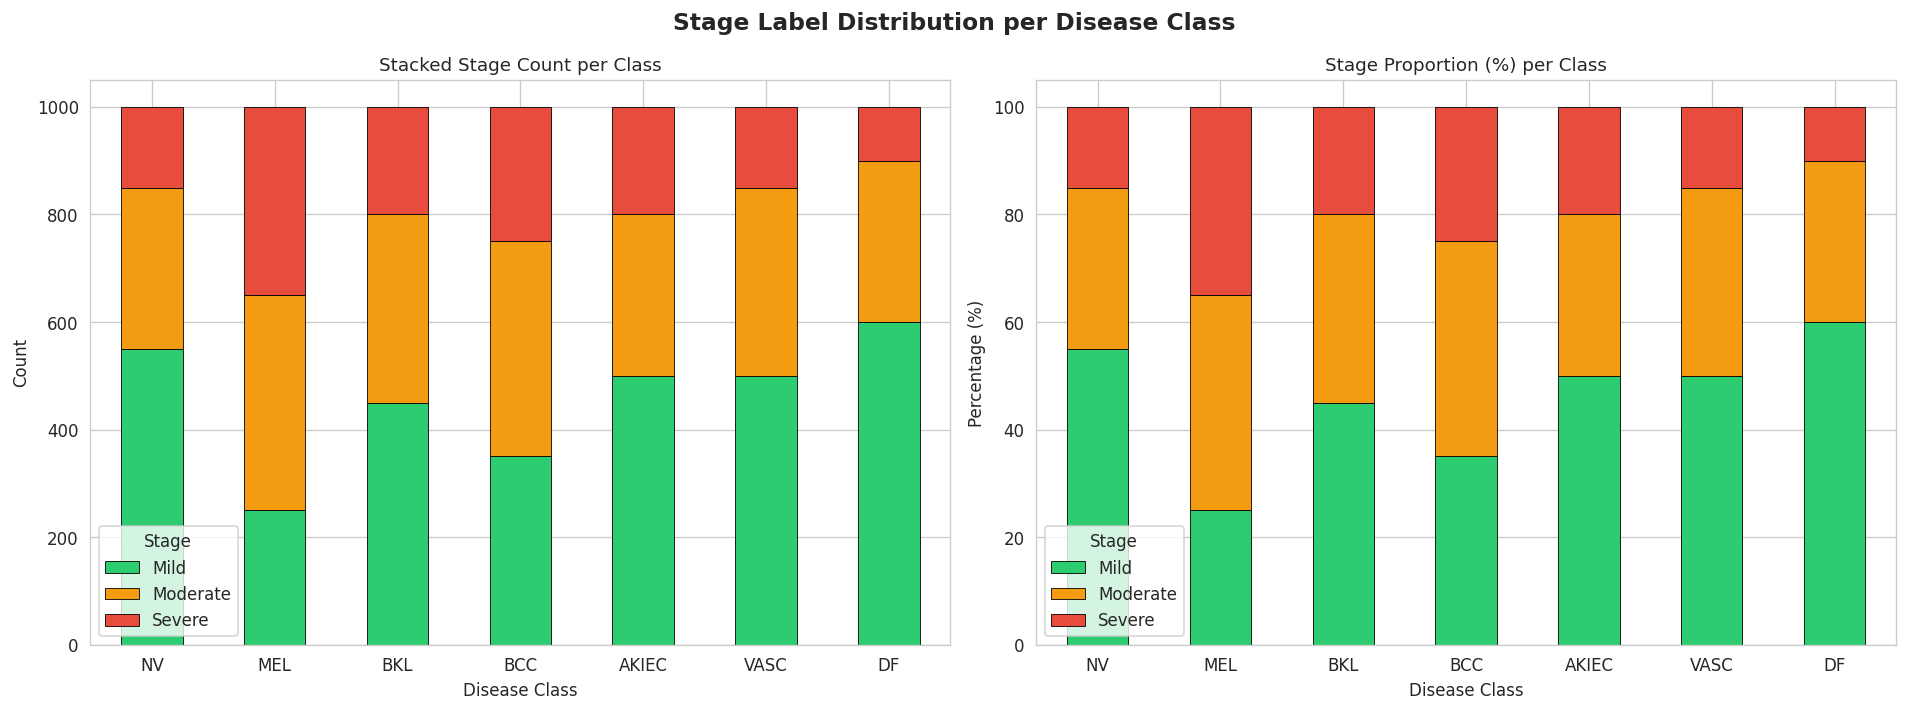

Saved: viz_stage_distribution.png


In [21]:
# ─── Visualisation 5: Stage Distribution per Disease Class ────────────────
stage_counts = (full_df[full_df['label'] != 'NORMAL']
                .groupby(['label', 'stage'])
                .size()
                .unstack(fill_value=0)
                .reindex(DISEASE_CLASSES))

# Reorder columns for logical visual order
for col in ['mild', 'moderate', 'severe']:
    if col not in stage_counts.columns:
        stage_counts[col] = 0
stage_counts = stage_counts[['mild', 'moderate', 'severe']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Stage Label Distribution per Disease Class', fontsize=14, fontweight='bold')

# Stacked bar
stage_counts.plot(kind='bar', stacked=True, ax=axes[0],
                  color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Stacked Stage Count per Class', fontsize=11)
axes[0].set_xlabel('Disease Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Stage', labels=['Mild', 'Moderate', 'Severe'])

# Normalised percentage bar
stage_pct = stage_counts.div(stage_counts.sum(axis=1), axis=0) * 100
stage_pct.plot(kind='bar', stacked=True, ax=axes[1],
               color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Stage Proportion (%) per Class', fontsize=11)
axes[1].set_xlabel('Disease Class')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Stage', labels=['Mild', 'Moderate', 'Severe'])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_stage_distribution.png'), bbox_inches='tight')
plt.show()
print('Saved: viz_stage_distribution.png')

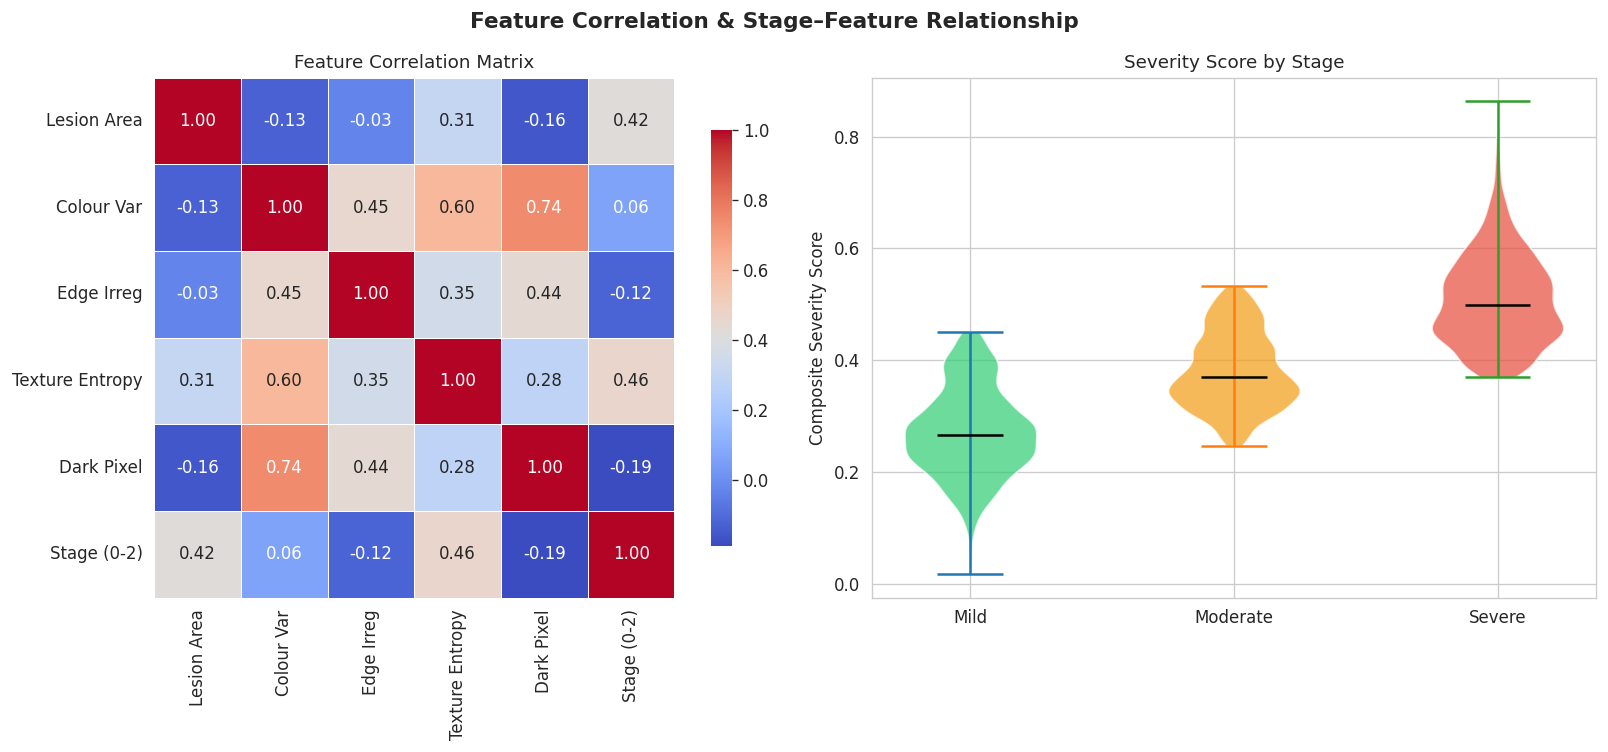

Saved: viz_feature_heatmap_stage_violin.png


In [22]:
# ─── Visualisation 6: Feature Correlation Heatmap ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Correlation & Stage–Feature Relationship', fontsize=13, fontweight='bold')

# Heatmap of feature correlations
corr_df = full_df[feat_cols + ['stage_numeric']].dropna()
corr_matrix = corr_df.corr()
rename_map = {
    'feat_lesion_area'    : 'Lesion Area',
    'feat_colour_var'     : 'Colour Var',
    'feat_edge_irreg'     : 'Edge Irreg',
    'feat_texture_entropy': 'Texture Entropy',
    'feat_dark_pixel'     : 'Dark Pixel',
    'stage_numeric'       : 'Stage (0-2)',
}
corr_matrix = corr_matrix.rename(index=rename_map, columns=rename_map)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, ax=axes[0], linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix', fontsize=11)

# Violin: severity score per stage (disease classes only)
plot_data = full_df[(full_df['label'] != 'NORMAL') & (full_df['stage'] != 'none')].copy()
stage_order = ['mild', 'moderate', 'severe']
stage_colors = {'mild': '#2ecc71', 'moderate': '#f39c12', 'severe': '#e74c3c'}
for i, stg in enumerate(stage_order):
    data = plot_data[plot_data['stage'] == stg]['severity_score'].dropna()
    parts = axes[1].violinplot([data], positions=[i], showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(stage_colors[stg])
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Mild', 'Moderate', 'Severe'])
axes[1].set_title('Severity Score by Stage', fontsize=11)
axes[1].set_ylabel('Composite Severity Score')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_feature_heatmap_stage_violin.png'), bbox_inches='tight')
plt.show()
print('Saved: viz_feature_heatmap_stage_violin.png')

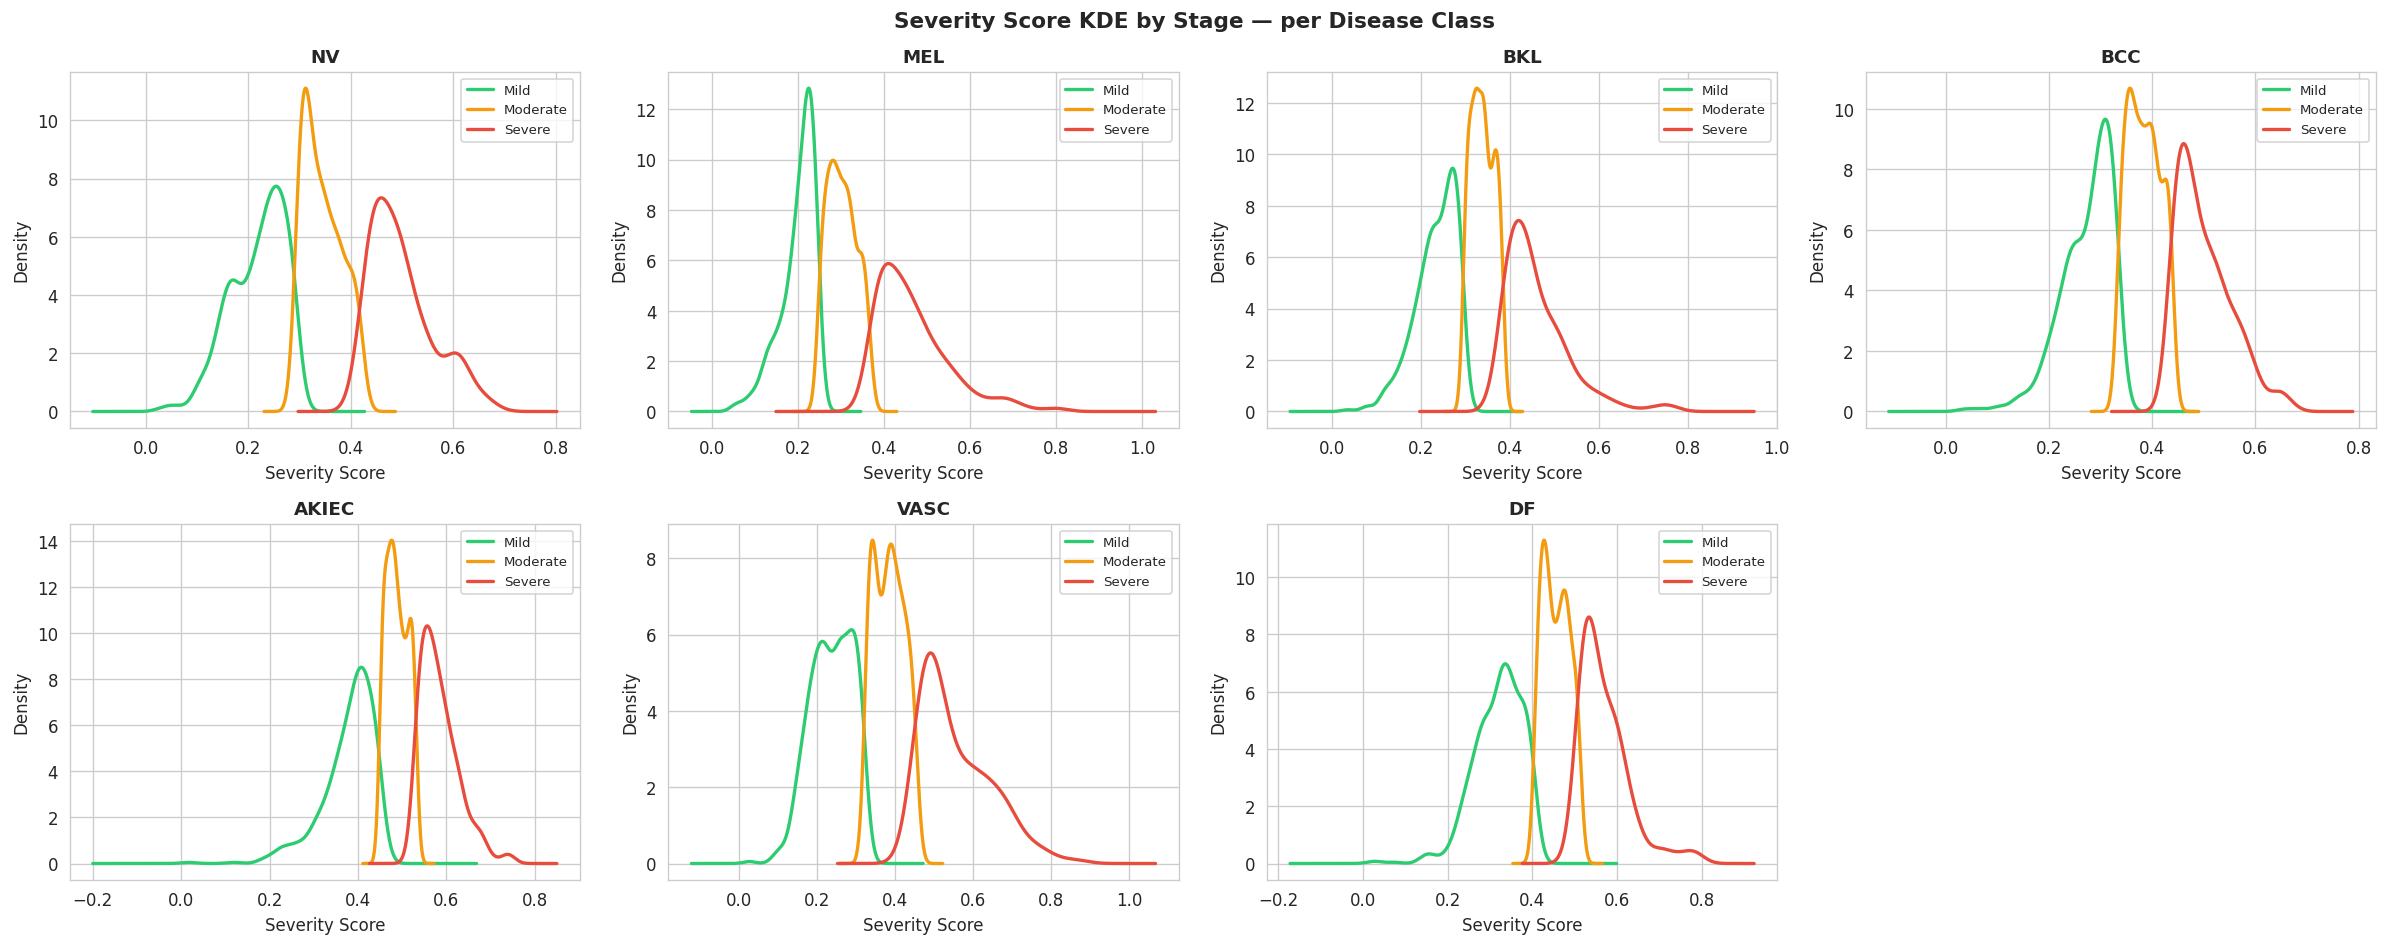

Saved: viz_per_class_stage_kde.png


In [23]:
# ─── Visualisation 7: Per-Class Severity Score Density (KDE) ──────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Severity Score KDE by Stage — per Disease Class', fontsize=13, fontweight='bold')
axes = axes.flatten()

stage_palette = {'mild': '#2ecc71', 'moderate': '#f39c12', 'severe': '#e74c3c'}

for idx, cls in enumerate(DISEASE_CLASSES):
    ax = axes[idx]
    cls_data = full_df[full_df['label'] == cls]
    for stg, color in stage_palette.items():
        vals = cls_data[cls_data['stage'] == stg]['severity_score'].dropna()
        if len(vals) > 1:
            vals.plot.kde(ax=ax, color=color, linewidth=2, label=stg.capitalize())
    ax.set_title(cls, fontsize=11, fontweight='bold')
    ax.set_xlabel('Severity Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

axes[7].axis('off')  # 8th panel unused
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_per_class_stage_kde.png'), bbox_inches='tight')
plt.show()
print('Saved: viz_per_class_stage_kde.png')

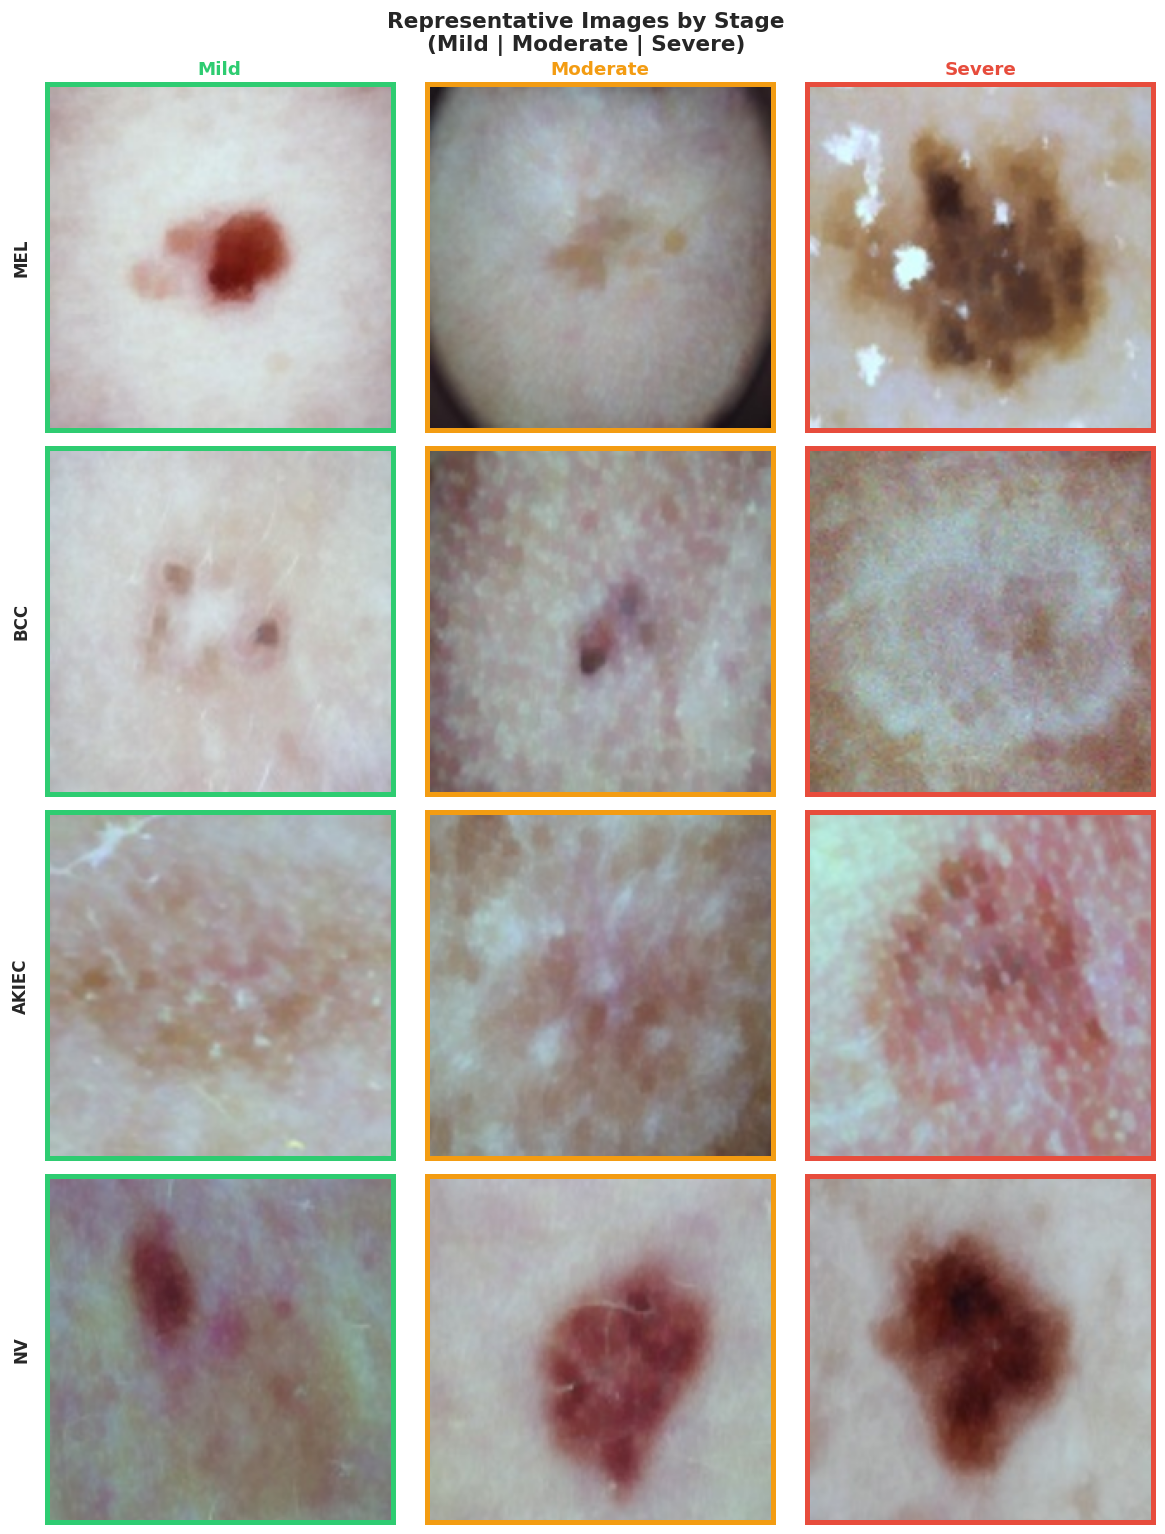

Saved: viz_sample_grid_by_stage.png


In [24]:
# ─── Visualisation 8: Sample Image Grid by Stage ──────────────────────────
# Show 3 representative images (mild / moderate / severe) for 4 diseases

SHOW_CLASSES = ['MEL', 'BCC', 'AKIEC', 'NV']
fig, axes = plt.subplots(len(SHOW_CLASSES), 3, figsize=(10, 13))
fig.suptitle('Representative Images by Stage\n(Mild | Moderate | Severe)',
             fontsize=13, fontweight='bold')

stage_col_labels = ['Mild', 'Moderate', 'Severe']
stage_colors_hex = ['#2ecc71', '#f39c12', '#e74c3c']

for row_idx, cls in enumerate(SHOW_CLASSES):
    cls_df = full_df[full_df['label'] == cls]
    for col_idx, stg in enumerate(['mild', 'moderate', 'severe']):
        ax = axes[row_idx, col_idx]
        stg_imgs = cls_df[cls_df['stage'] == stg]['image_path'].tolist()
        if stg_imgs:
            # Pick the median severity score sample for most representativeness
            stg_sub  = cls_df[cls_df['stage'] == stg].copy()
            med_idx  = (stg_sub['severity_score'] - stg_sub['severity_score'].median()).abs().idxmin()
            img_path = stg_sub.loc[med_idx, 'image_path']
            try:
                img = Image.open(img_path).convert('RGB').resize((200, 200))
                ax.imshow(img)
            except:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)

        border_color = stage_colors_hex[col_idx]
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)

        if row_idx == 0:
            ax.set_title(stage_col_labels[col_idx], fontsize=11,
                         color=border_color, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight='bold', rotation=90, labelpad=10)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_sample_grid_by_stage.png'), bbox_inches='tight')
plt.show()
print('Saved: viz_sample_grid_by_stage.png')

## Section 7: Generate Final CSVs for SkinFusionNet

In [25]:
# ─── Build SkinFusionNet-ready dataset CSV ─────────────────────────────────
#
# Columns:
#   image_path        — absolute path to image
#   label             — disease class (NV, MEL, BKL, BCC, AKIEC, VASC, DF, NORMAL)
#   label_id          — integer class index (0–7)
#   stage             — mild / moderate / severe / none
#   stage_id          — 0=mild, 1=moderate, 2=severe, -1=none
#   source            — original / aug / gan
#   severity_score    — continuous score [0,1] (0 for NORMAL)
#   feat_lesion_area  — extracted feature
#   feat_colour_var   — extracted feature
#   feat_edge_irreg   — extracted feature
#   feat_texture_entropy — extracted feature
#   feat_dark_pixel   — extracted feature

LABEL_MAP = {cls: i for i, cls in enumerate(ALL_CLASSES)}
STAGE_MAP  = {'mild': 0, 'moderate': 1, 'severe': 2, 'none': -1}

full_df['label_id']  = full_df['label'].map(LABEL_MAP)
full_df['stage_id']  = full_df['stage'].map(STAGE_MAP)

# Final column order
out_cols = [
    'image_path', 'label', 'label_id', 'stage', 'stage_id',
    'source', 'severity_score',
    'feat_lesion_area', 'feat_colour_var', 'feat_edge_irreg',
    'feat_texture_entropy', 'feat_dark_pixel'
]

final_df = full_df[out_cols].copy()
final_df = final_df.dropna(subset=['image_path', 'label', 'stage'])

print('Final dataset summary:')
print(f'  Total images : {len(final_df)}')
print(f'  Classes      : {sorted(final_df["label"].unique())}')
print(f'  Stages       : {sorted(final_df["stage"].unique())}')
print()
print(final_df.groupby(['label', 'stage']).size().unstack(fill_value=0))

Final dataset summary:
  Total images : 8000
  Classes      : ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NORMAL', 'NV', 'VASC']
  Stages       : ['mild', 'moderate', 'none', 'severe']

stage   mild  moderate  none  severe
label                               
AKIEC    500       300     0     200
BCC      350       400     0     250
BKL      450       350     0     200
DF       600       300     0     100
MEL      250       400     0     350
NORMAL     0         0  1000       0
NV       550       300     0     150
VASC     500       350     0     150


In [26]:
# ─── Save: final_metadata_with_stages.csv ─────────────────────────────────
META_STAGE_CSV = os.path.join(OUTPUT_DIR, 'final_metadata_with_stages.csv')
final_df.to_csv(META_STAGE_CSV, index=False)
print(f'Saved: {META_STAGE_CSV}')
print(f'Rows: {len(final_df)} | Columns: {list(final_df.columns)}')

Saved: /content/drive/MyDrive/DermAugFramework/SkinFusionNet_Labels/final_metadata_with_stages.csv
Rows: 8000 | Columns: ['image_path', 'label', 'label_id', 'stage', 'stage_id', 'source', 'severity_score', 'feat_lesion_area', 'feat_colour_var', 'feat_edge_irreg', 'feat_texture_entropy', 'feat_dark_pixel']


In [27]:
# ─── Stratified Train / Validation / Test split ────────────────────────────
# Split: 70% train | 15% val | 15% test
# Stratified on (label, stage) to maintain class+stage balance.

from sklearn.model_selection import train_test_split

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Create a combined stratification key
final_df = final_df.copy()
final_df['strat_key'] = final_df['label'] + '_' + final_df['stage']

# First split: train vs (val + test)
train_df, temp_df = train_test_split(
    final_df, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=final_df['strat_key'], random_state=42
)

# Second split: val vs test from temp
val_df, test_df = train_test_split(
    temp_df, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=temp_df['strat_key'], random_state=42
)

train_df = train_df.drop(columns='strat_key')
val_df   = val_df.drop(columns='strat_key')
test_df  = test_df.drop(columns='strat_key')

train_df['split'] = 'train'
val_df['split']   = 'val'
test_df['split']  = 'test'

split_df = pd.concat([train_df, val_df, test_df]).drop(columns='strat_key', errors='ignore')

print('Split sizes:')
print(f'  Train : {len(train_df):5d} ({len(train_df)/len(final_df)*100:.1f}%)')
print(f'  Val   : {len(val_df):5d} ({len(val_df)/len(final_df)*100:.1f}%)')
print(f'  Test  : {len(test_df):5d} ({len(test_df)/len(final_df)*100:.1f}%)')
print(f'  Total : {len(split_df)}')

Split sizes:
  Train :  5600 (70.0%)
  Val   :  1200 (15.0%)
  Test  :  1200 (15.0%)
  Total : 8000


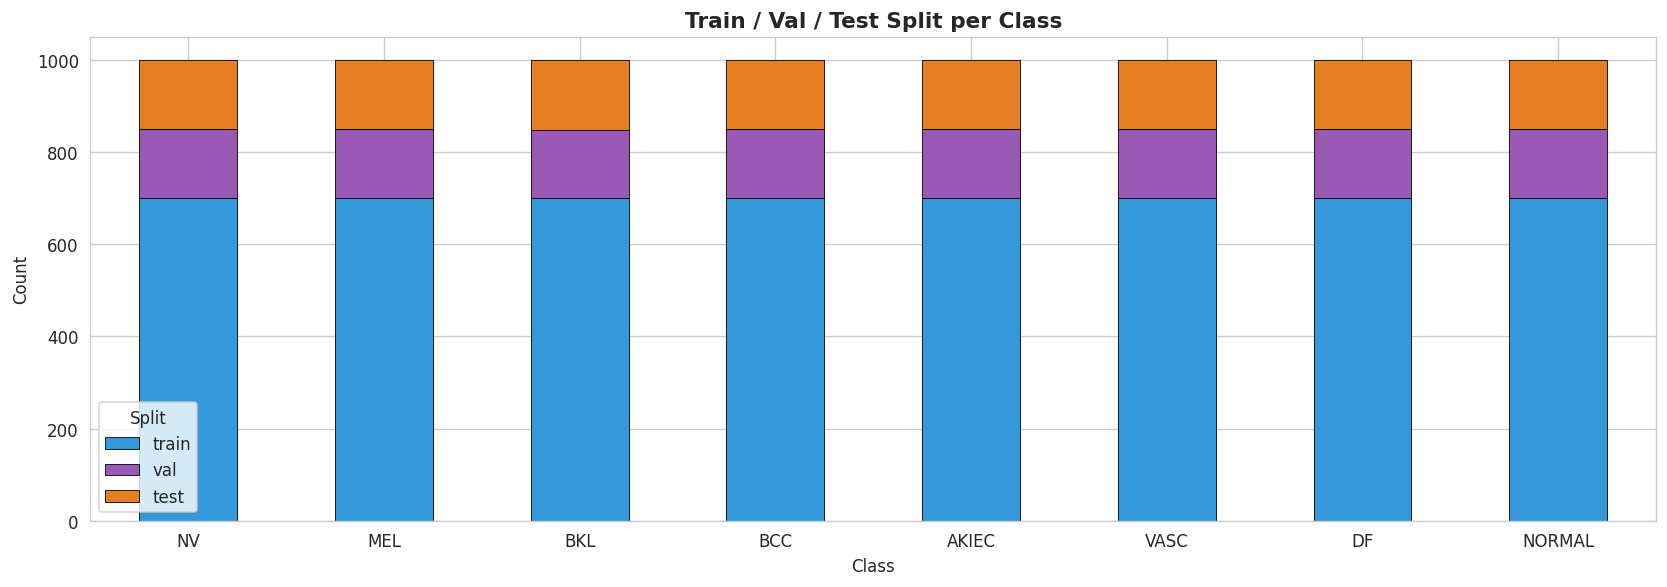

Saved: viz_train_val_test_split.png


In [28]:
# ─── Visualisation 9: Split Distribution Stacked Bars ────────────────────
split_counts = split_df.groupby(['label', 'split']).size().unstack(fill_value=0)
split_counts = split_counts.reindex(ALL_CLASSES)

fig, ax = plt.subplots(figsize=(14, 5))
split_counts[['train', 'val', 'test']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='black', linewidth=0.5
)
ax.set_title('Train / Val / Test Split per Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Split')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_train_val_test_split.png'), bbox_inches='tight')
plt.show()
print('Saved: viz_train_val_test_split.png')

In [29]:
# ─── Save all output CSVs ──────────────────────────────────────────────────

# 1. Full dataset with splits and stages — primary SkinFusionNet input
SKINFUSIONNET_CSV = os.path.join(OUTPUT_DIR, 'skinfusionnet_dataset.csv')
split_df.to_csv(SKINFUSIONNET_CSV, index=False)
print(f'Saved: {SKINFUSIONNET_CSV}')

# 2. Train-only CSV
TRAIN_CSV = os.path.join(OUTPUT_DIR, 'train.csv')
train_df.to_csv(TRAIN_CSV, index=False)
print(f'Saved: {TRAIN_CSV}  ({len(train_df)} rows)')

# 3. Validation CSV
VAL_CSV = os.path.join(OUTPUT_DIR, 'val.csv')
val_df.to_csv(VAL_CSV, index=False)
print(f'Saved: {VAL_CSV}  ({len(val_df)} rows)')

# 4. Test CSV
TEST_CSV = os.path.join(OUTPUT_DIR, 'test.csv')
test_df.to_csv(TEST_CSV, index=False)
print(f'Saved: {TEST_CSV}  ({len(test_df)} rows)')

# 5. Class + stage label map JSON
import json
label_map_json = {
    'label_to_id'       : LABEL_MAP,
    'id_to_label'       : {v: k for k, v in LABEL_MAP.items()},
    'stage_to_id'       : STAGE_MAP,
    'id_to_stage'       : {v: k for k, v in STAGE_MAP.items()},
    'num_disease_classes': len(ALL_CLASSES),
    'num_stage_classes' : 3,
    'classes'           : ALL_CLASSES,
    'stages'            : STAGES + ['none'],
    'feature_weights'   : FEATURE_WEIGHTS,
    'stage_ratios'      : STAGE_RATIOS,
    'notes': (
        'NORMAL class has stage=none / stage_id=-1. '
        'SkinFusionNet should mask stage head loss for NORMAL inputs.'
    )
}
MAP_JSON = os.path.join(OUTPUT_DIR, 'label_map.json')
with open(MAP_JSON, 'w') as f:
    json.dump(label_map_json, f, indent=2)
print(f'Saved: {MAP_JSON}')

print('All output files:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) // 1024
    print(f'   {f:55s} {size_kb:>6} KB')

Saved: /content/drive/MyDrive/DermAugFramework/SkinFusionNet_Labels/skinfusionnet_dataset.csv
Saved: /content/drive/MyDrive/DermAugFramework/SkinFusionNet_Labels/train.csv  (5600 rows)
Saved: /content/drive/MyDrive/DermAugFramework/SkinFusionNet_Labels/val.csv  (1200 rows)
Saved: /content/drive/MyDrive/DermAugFramework/SkinFusionNet_Labels/test.csv  (1200 rows)
Saved: /content/drive/MyDrive/DermAugFramework/SkinFusionNet_Labels/label_map.json
All output files:
   feature_cache.csv                                         1419 KB
   final_metadata_with_stages.csv                            1639 KB
   label_map.json                                               1 KB
   skinfusionnet_dataset.csv                                 1682 KB
   test.csv                                                   252 KB
   train.csv                                                 1180 KB
   val.csv                                                    250 KB
   viz_class_distribution.png                       

## Section 8: Comprehensive Final Visualisations

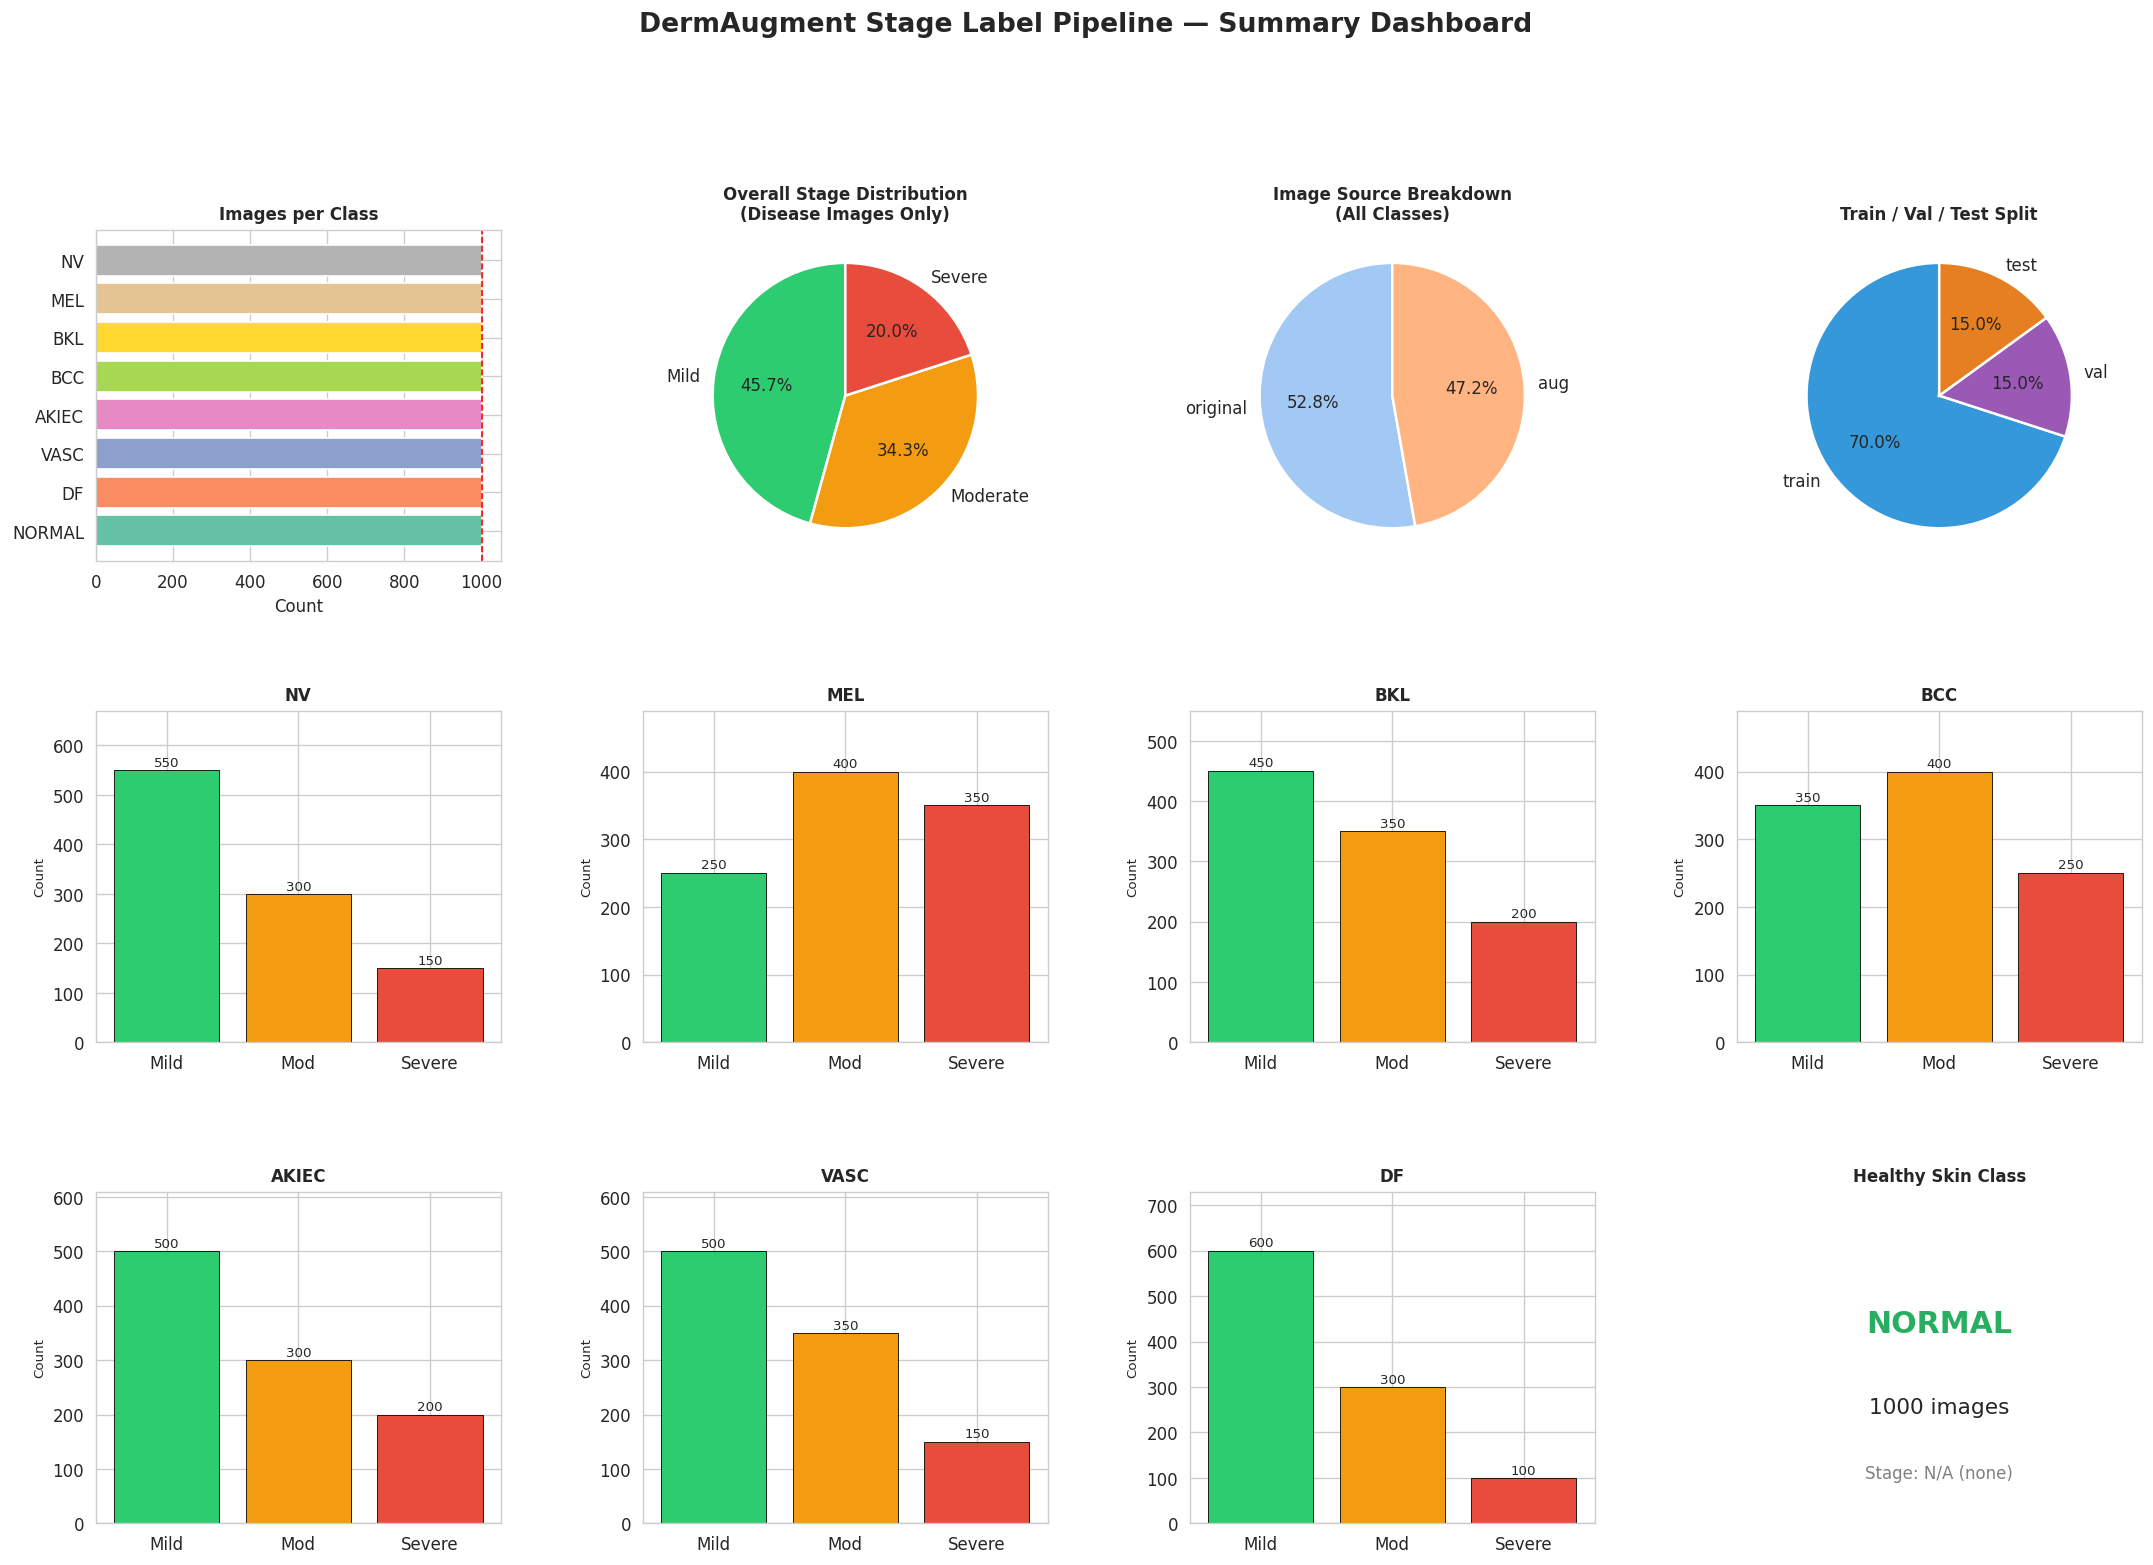

Saved: viz_pipeline_summary_dashboard.png


In [31]:
# ─── Visualisation 10: Full Pipeline Summary Dashboard ────────────────────
fig = plt.figure(figsize=(22, 14))
fig.suptitle('DermAugment Stage Label Pipeline — Summary Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

# Panel 1: Class counts
ax1 = fig.add_subplot(gs[0, 0])
counts_all = split_df['label'].value_counts().reindex(ALL_CLASSES)
ax1.barh(counts_all.index[::-1], counts_all.values[::-1],
         color=[PALETTE[i] for i in range(len(ALL_CLASSES))])
ax1.set_title('Images per Class', fontsize=10, fontweight='bold')
ax1.set_xlabel('Count')
ax1.axvline(1000, color='red', linestyle='--', linewidth=1)

# Panel 2: Stage distribution (overall)
ax2 = fig.add_subplot(gs[0, 1])
stage_overall = split_df[split_df['stage'] != 'none']['stage'].value_counts()
stage_overall = stage_overall.reindex(['mild', 'moderate', 'severe'], fill_value=0)
ax2.pie(stage_overall.values, labels=['Mild', 'Moderate', 'Severe'],
        autopct='%1.1f%%', colors=['#2ecc71', '#f39c12', '#e74c3c'],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, startangle=90)
ax2.set_title('Overall Stage Distribution\n(Disease Images Only)', fontsize=10, fontweight='bold')

# Panel 3: Source breakdown
ax3 = fig.add_subplot(gs[0, 2])
src_overall = split_df['source'].value_counts()
ax3.pie(src_overall.values, labels=src_overall.index,
        autopct='%1.1f%%', colors=sns.color_palette('pastel'),
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, startangle=90)
ax3.set_title('Image Source Breakdown\n(All Classes)', fontsize=10, fontweight='bold')

# Panel 4: Split sizes
ax4 = fig.add_subplot(gs[0, 3])
split_sizes = split_df['split'].value_counts()
ax4.pie(split_sizes.values, labels=split_sizes.index,
        autopct='%1.1f%%', colors=['#3498db', '#9b59b6', '#e67e22'],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, startangle=90)
ax4.set_title('Train / Val / Test Split', fontsize=10, fontweight='bold')

# Panel 5-11: Per-class stage bars
for idx, cls in enumerate(DISEASE_CLASSES):
    row = 1 + idx // 4
    col = idx % 4
    ax = fig.add_subplot(gs[row, col])
    cls_stage = (split_df[split_df['label'] == cls]
                 .groupby('stage').size()
                 .reindex(['mild', 'moderate', 'severe'], fill_value=0))
    bars = ax.bar(['Mild', 'Mod', 'Severe'], cls_stage.values,
                  color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, cls_stage.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', va='bottom', fontsize=8)
    ax.set_title(cls, fontsize=10, fontweight='bold')
    ax.set_ylabel('Count', fontsize=8)
    ax.set_ylim(0, max(cls_stage.values) * 1.2 + 10)

# Last panel: NORMAL info
ax_last = fig.add_subplot(gs[2, 3])
normal_count = len(split_df[split_df['label'] == 'NORMAL'])
ax_last.text(0.5, 0.6, 'NORMAL', ha='center', va='center',
             fontsize=18, fontweight='bold', color='#27ae60', transform=ax_last.transAxes)
ax_last.text(0.5, 0.35, f'{normal_count} images', ha='center', va='center',
             fontsize=13, transform=ax_last.transAxes)
ax_last.text(0.5, 0.15, 'Stage: N/A (none)', ha='center', va='center',
             fontsize=10, color='grey', transform=ax_last.transAxes)
ax_last.set_title('Healthy Skin Class', fontsize=10, fontweight='bold')
ax_last.axis('off')

plt.savefig(os.path.join(OUTPUT_DIR, 'viz_pipeline_summary_dashboard.png'),
            bbox_inches='tight', dpi=130)
plt.show()
print('Saved: viz_pipeline_summary_dashboard.png')

## Section 9: Final Verification & Pipeline Summary

In [34]:
# ─── Final Verification ────────────────────────────────────────────────────
print('=' * 65)
print('  STAGE LABEL GENERATION PIPELINE — COMPLETE')
print('=' * 65)

print(f'Final Dataset Directory : {FINAL_DATASET_DIR}')
print(f'Labels & CSV Directory  : {OUTPUT_DIR}')

print(f'\n{"Class":8s} {"Total":7s} {"Mild":7s} {"Moderate":10s} {"Severe":7s} {"Source"}')
print('─' * 65)

all_ok = True
for cls in ALL_CLASSES:
    cls_df = split_df[split_df['label'] == cls]
    total  = len(cls_df)
    mild   = len(cls_df[cls_df['stage'] == 'mild'])
    mod    = len(cls_df[cls_df['stage'] == 'moderate'])
    severe = len(cls_df[cls_df['stage'] == 'severe'])
    if cls == 'NORMAL':
        src_info = f'raw:{NORMAL_RAW_COUNT} + aug:{total - NORMAL_RAW_COUNT}'
        stage_str = 'N/A (none)'
        print(f'{cls:8s} {total:7d} {stage_str:26s} {src_info}')
    else:
        ok = total == TARGET_PER_CLASS
        if not ok: all_ok = False
        flag = '✅' if ok else '⚠️'
        print(f'{cls:8s} {total:7d} {mild:7d} {mod:10d} {severe:7d}  {flag}')

print('─' * 65)
print(f'{"TOTAL":8s} {len(split_df):7d}')
print()

if all_ok:
    print('ALL DISEASE CLASSES: 1000 images each')
else:
    print('Some classes may need review')

print('Output CSVs:')
csv_files = ['final_metadata_with_stages.csv', 'skinfusionnet_dataset.csv',
             'train.csv', 'val.csv', 'test.csv', 'label_map.json']
for f in csv_files:
    p = os.path.join(OUTPUT_DIR, f)
    exists = '✅' if os.path.exists(p) else '❌'
    print(f'  {exists} {f}')

  STAGE LABEL GENERATION PIPELINE — COMPLETE
Final Dataset Directory : /content/drive/MyDrive/DermAugFramework/ISIC2018_Final_8Class
Labels & CSV Directory  : /content/drive/MyDrive/DermAugFramework/SkinFusionNet_Labels

Class    Total   Mild    Moderate   Severe  Source
─────────────────────────────────────────────────────────────────
NV          1000     550        300     150  ✅
MEL         1000     250        400     350  ✅
BKL         1000     450        350     200  ✅
BCC         1000     350        400     250  ✅
AKIEC       1000     500        300     200  ✅
VASC        1000     500        350     150  ✅
DF          1000     600        300     100  ✅
NORMAL      1000 N/A (none)                 raw:124 + aug:876
─────────────────────────────────────────────────────────────────
TOTAL       8000

ALL DISEASE CLASSES: 1000 images each
Output CSVs:
  ✅ final_metadata_with_stages.csv
  ✅ skinfusionnet_dataset.csv
  ✅ train.csv
  ✅ val.csv
  ✅ test.csv
  ✅ label_map.json


In [35]:
# ─── Preview: Sample rows from final CSV ──────────────────────────────────
print('Sample rows from skinfusionnet_dataset.csv:\n')
display_cols = ['image_path', 'label', 'label_id', 'stage', 'stage_id', 'split', 'severity_score']
sample = split_df[display_cols].sample(12, random_state=42).reset_index(drop=True)

# Shorten paths for display
sample['image_path'] = sample['image_path'].apply(lambda p: '.../' + '/'.join(p.split('/')[-2:]))
print(sample.to_string(index=False))

Sample rows from skinfusionnet_dataset.csv:

                 image_path  label  label_id    stage  stage_id split  severity_score
   .../NV/original_0363.jpg     NV         0     mild         0 train        0.160421
.../AKIEC/original_0316.jpg  AKIEC         4     mild         0 train        0.362031
   .../NV/original_0191.jpg     NV         0     mild         0 train        0.290465
.../AKIEC/original_0096.jpg  AKIEC         4     mild         0 train        0.393001
     .../VASC/aug_00838.jpg   VASC         5     mild         0 train        0.310524
  .../MEL/original_0466.jpg    MEL         1     mild         0 train        0.188061
  .../BCC/original_0342.jpg    BCC         3 moderate         1 train        0.435040
  .../MEL/original_0189.jpg    MEL         1 moderate         1 train        0.345288
  .../MEL/original_0222.jpg    MEL         1 moderate         1 train        0.354816
   .../NORMAL/aug_00735.jpg NORMAL         7     none        -1 train        0.000000
  .../BKL